In [1]:
import sys
import os

# Get the current working directory
cwd = os.getcwd()
print(f"Current Working Directory: {cwd}")

# Define the path to the 'mapelite' folder
# We assume the notebook is running from the root 'Quality-Diversity-...' folder
mapelite_path = os.path.join(cwd, 'mapelite')

# Add it to the system path so Python can find config.py, utils.py, etc.
if mapelite_path not in sys.path:
    sys.path.append(mapelite_path)
    print(f"Added '{mapelite_path}' to sys.path")

Current Working Directory: d:\dev\Quality-Diversity-for-Racing-Track-Design
Added 'd:\dev\Quality-Diversity-for-Racing-Track-Design\mapelite' to sys.path


In [2]:
import numpy as np
import random
import os

import ribs
from ribs.archives import CVTArchive
from ribs.schedulers import Scheduler
from sklearn.cluster import KMeans

from emitter import CustomEmitter
from mapelite.qd_runner import QDRunner

d:\dev\Quality-Diversity-for-Racing-Track-Design\mapelite\qd_runner.py:137: SyntaxWarning: invalid escape sequence '\e'
  self._umap_model = joblib.load("mapelite\embeddings\models\model_metrics_VAE\model_metrics_VAE_latent32_umap.joblib")
d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from mapelite.config import (
    SOLUTION_DIM,
    BATCH_SIZE,
    CVT_DIR,
    BUFFER_FILENAME,
    CHECKPOINT_DIR,
    STATS_FILENAME,
    ELITES_FILENAME,
    HEATMAP_DIR,
    GRIDPLOT_DIR,
    INVALID_SCORE,
    ITERATIONS
)


# --- CVT MAP-Elites specific config ---
checkpoint_dir = os.path.join(CVT_DIR, CHECKPOINT_DIR)
heatmap_dir = os.path.join(CVT_DIR, HEATMAP_DIR)
gridplot_dir = os.path.join(CVT_DIR, GRIDPLOT_DIR)
stats_path = os.path.join(CVT_DIR, STATS_FILENAME)
buffer_path = os.path.join(CVT_DIR, BUFFER_FILENAME)

EMBEDDING_DIM = 32
SEED = 67
ELITES_OUTPUT = os.path.join(CVT_DIR, ELITES_FILENAME)
ALGORITHM_LABEL = "CVT MAP-Elites (CVTArchive + VAE latent descriptors)"

# --- CVT Archive parameters ---
CVT_CELLS = 200          # number of Voronoi regions (centroids) in the archive
CVT_MEASURES = [(-5, 5)] * EMBEDDING_DIM  # bounds per measure dimension (VAE latent space)
PRECOMP_EMBEDDINGS_PATH = "mapelite/embeddings/datasets/embeddings/track_embeddings_metrics_32_mu.npz"

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

In [ ]:
# --- Initialize directories ---
os.makedirs(CVT_DIR, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(heatmap_dir, exist_ok=True)
os.makedirs(gridplot_dir, exist_ok=True)

# --- DASK SETUP ---
client, cluster, evaluator_future = QDRunner.setup_dask(BATCH_SIZE)

Setting up Dask LocalCluster...
Dask Dashboard link: http://127.0.0.1:8787/status
Loading model from mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_latent32.pth...
Model loaded with latent_dim=32
Evaluator scattered to 10 Dask workers


In [5]:
# import umap
# # Cell to calculate and save UMAP model of precomputed embeddings
# embeddings_data = np.load(PRECOMP_EMBEDDINGS_PATH)["embeddings"]
# print(f"Loaded precomputed embeddings with shape: {embeddings_data.shape}")

# # Fit UMAP to the precomputed embeddings
# umap_model = umap.UMAP(n_components=EMBEDDING_DIM, random_state=SEED)
# umap_model = umap_model.fit(embeddings_data)

# #save the trained model
# import joblib
# umap_model_path = os.path.join(CVT_DIR, "umap_model.joblib")

# joblib.dump(umap_model, umap_model_path)
# print(f"Saved UMAP model to: {umap_model_path}")


# #print umap max and min x,y values
# umap_embeddings = umap_model.transform(embeddings_data)
# print(f"UMAP embeddings x,y borders:")
# print(f"x: min={umap_embeddings[:,0].min()}, max={umap_embeddings[:,0].max()}")
# print(f"y: min={umap_embeddings[:,1].min()}, max={umap_embeddings[:,1].max()}")




In [6]:
# --------------------------------------------------------------
# Resume from latest checkpoint if available,
# otherwise compute CVT centroids and build archive from scratch
# --------------------------------------------------------------
state = QDRunner.resume_from_checkpoint(checkpoint_dir, stats_path)

if state["scheduler"] is not None:
    scheduler = state["scheduler"]
    archive   = state["archive"]
else:
    print("Computing CVT centroids...")
    embeddings_data = np.load(PRECOMP_EMBEDDINGS_PATH)["embeddings"]
    print(f"Loaded {embeddings_data.shape[0]} embeddings ({embeddings_data.shape[1]}D) from {PRECOMP_EMBEDDINGS_PATH}")

    km = KMeans(n_clusters=CVT_CELLS, random_state=SEED, n_init=10)
    km.fit(embeddings_data)
    custom_centroids = km.cluster_centers_
    print(f"Computed {custom_centroids.shape[0]} centroids via k-means")

    wss = km.inertia_
    print(f"Within-Cluster Sum of Squares (WSS / inertia): {wss:.4f}")

    archive = CVTArchive(
        solution_dim=SOLUTION_DIM,
        ranges=CVT_MEASURES,
        cells=CVT_CELLS,
        seed=SEED,
        custom_centroids=custom_centroids,
    )

    emitter = CustomEmitter(
        archive,
        solution_dim=SOLUTION_DIM,
        batch_size=BATCH_SIZE,
        bounds=[(0, 600)] * (SOLUTION_DIM - 1) + [(0, float("inf"))]
    )

    scheduler = Scheduler(archive, [emitter])
    print("Archive, emitter, and scheduler created.")

# --- Build the QDRunner ---
runner = QDRunner(
    scheduler=scheduler, archive=archive, client=client,
    evaluator_future=evaluator_future,
    checkpoint_dir=checkpoint_dir, heatmap_dir=heatmap_dir,
    gridplot_dir=gridplot_dir, stats_path=stats_path,
    buffer_path=buffer_path, seed=SEED,
    centroids=archive.centroids,
)
runner.load_state(
    start_iter=state["start_iter"],
    global_best_score=state["global_best_score"],
    global_best_id=state["global_best_id"],
    stats=state["stats"],
)


[Resume] No checkpoint found — starting fresh.
[Resume] Resumed stats with 0 entries
Computing CVT centroids...
Loaded 10000 embeddings (32D) from mapelite/embeddings/datasets/embeddings/track_embeddings_metrics_32_mu.npz
Computed 200 centroids via k-means
Within-Cluster Sum of Squares (WSS / inertia): 69467.7891
Archive, emitter, and scheduler created.
[Buffer] No existing buffer found — starting empty.


In [ ]:
# Run main loop
global_best_score, global_best_id, stats = runner.run(
    total_iters=ITERATIONS,
    start_iter=state["start_iter"],
)

Emitter.ask() called for iteration 1


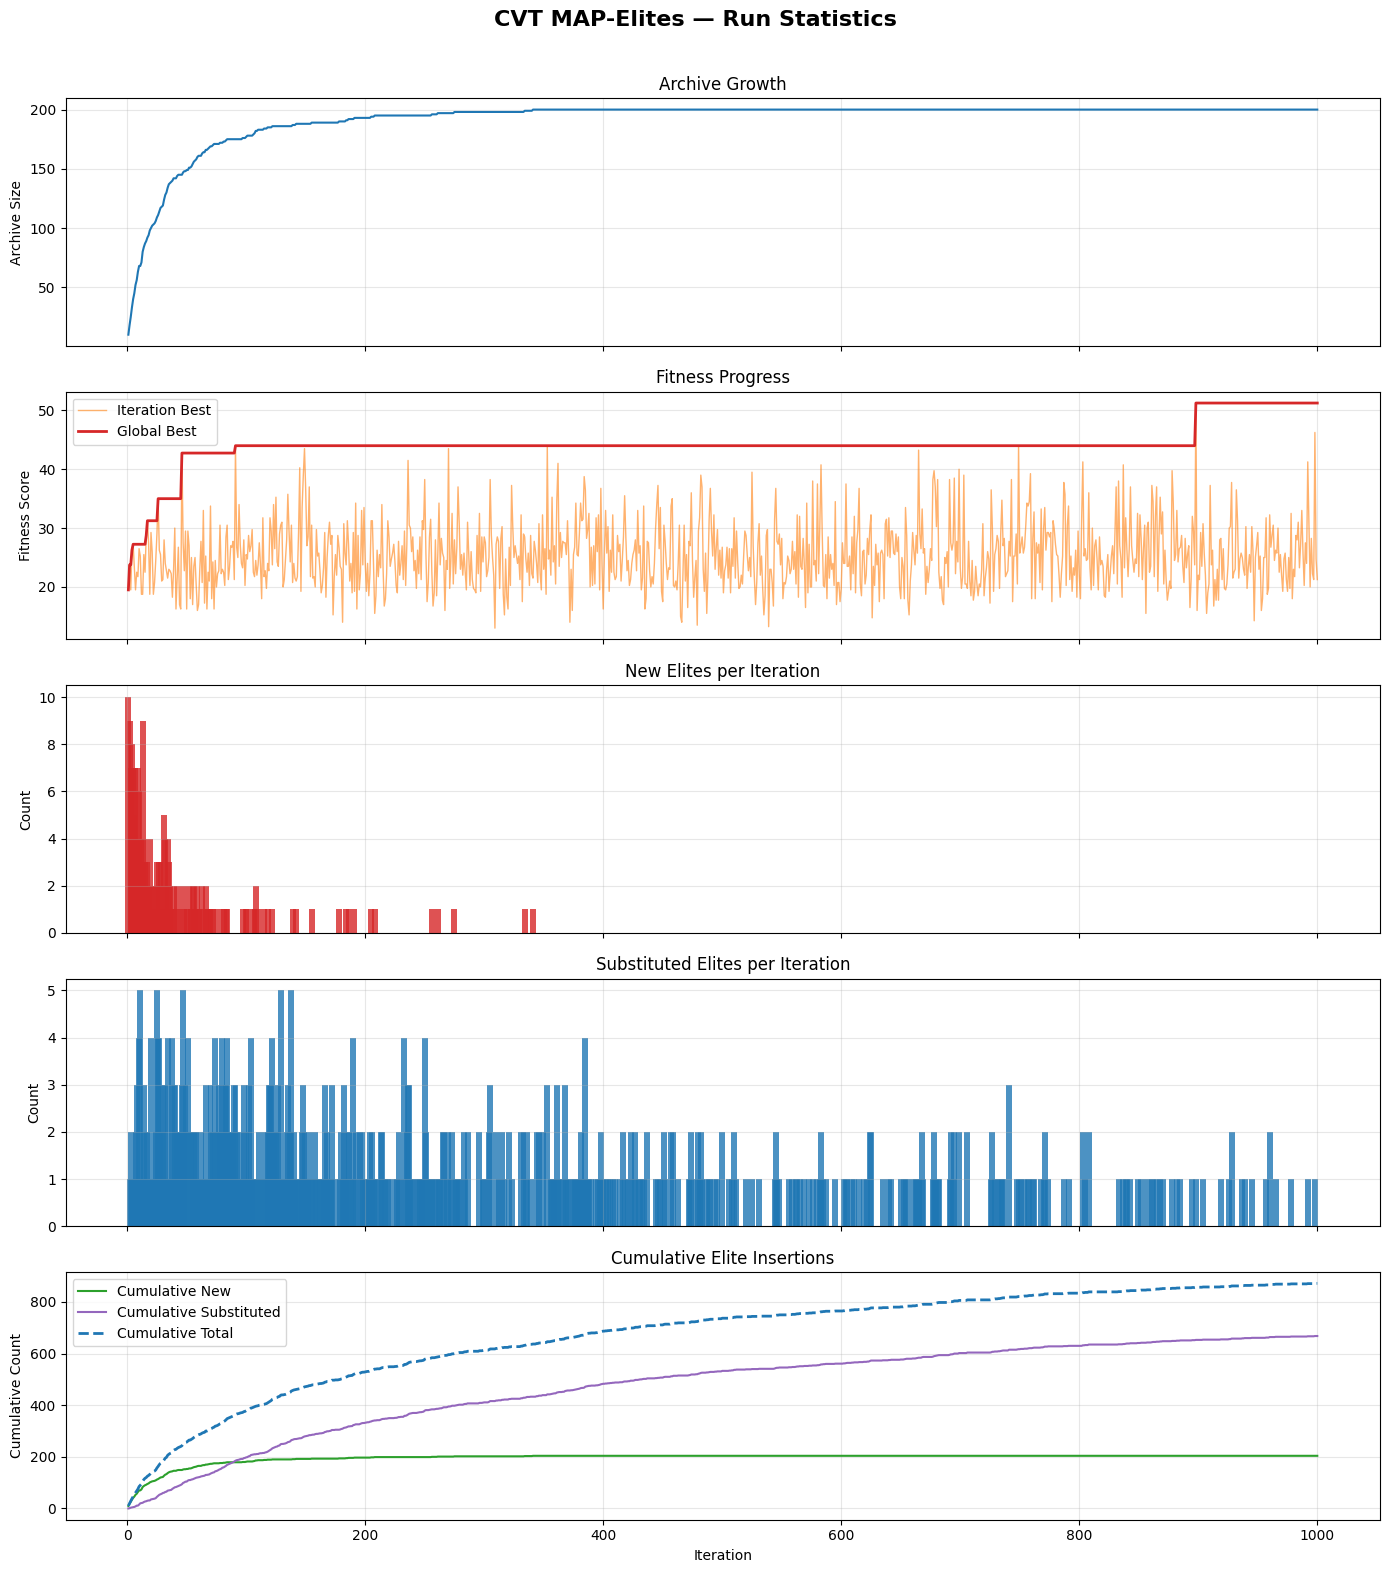


  CVT MAP-Elites Summary
  Total iterations:        1000
  Final archive size:      200
  Global best fitness:     51.2500
  Total new elites:        204
  Total substituted:       668
  Avg new elites/iter:     0.20
  Avg substituted/iter:    0.67


In [ ]:
runner.visualizer.plot_stats(title="CVT MAP-Elites")

In [ ]:
runner.visualizer.export_elites(
    output_path=ELITES_OUTPUT,
    algorithm_label=ALGORITHM_LABEL,
    seed=SEED,
    global_best_score=global_best_score,
    global_best_id=global_best_id,
)

Saved 200 elites to data/elites/cvt.json
  Best fitness:  51.2500 (ID=897.1698478772297)
  Worst fitness: 10.2500
  File size:     2164.1 KB
